In [72]:
import pandas as pd
df = pd.read_csv(r"/home/umoujahid/visualisation_project/data/Global-YouTube-Statistics_duplicates_dropped.csv")

In [73]:
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [74]:
df.dropna(subset=["created_year"],inplace = True)

In [75]:
df.isna().sum()

rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    120
Abbreviation                               120
channel_type                                27
video_views_rank                             0
country_rank                               114
channel_type_rank                           29
video_views_for_the_last_30_days            51
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               332
created_year                                 0
created_month                                0
created_date 

In [76]:
years = df["created_year"].unique()
years

array([2006., 2012., 2013., 2015., 2010., 2016., 2018., 2014., 2007.,
       2020., 2008., 2005., 2011., 2009., 2017., 2021., 1970., 2019.,
       2022.])

In [77]:
# drop the outlier 1970 (impossible )
df.drop(df[df["created_year"] == years[-3]].index, inplace=True)

In [78]:
df["created_year"].unique()

array([2006., 2012., 2013., 2015., 2010., 2016., 2018., 2014., 2007.,
       2020., 2008., 2005., 2011., 2009., 2017., 2021., 2019., 2022.])

In [79]:
# create the column complete_date by combinng the columns created date , month and year , using time series method in pandas
df["created_complete_date"] = pd.to_datetime(df["created_year"].astype(int).astype(str) 
                                             + "-" + df["created_month"].astype(str) 
                                             + "-" + df["created_date"].astype(int).astype(str) ,
                                             format="%Y-%b-%d" ,dayfirst=False).apply(lambda x: x.strftime("%Y"))

In [80]:
df["created_complete_date"]

0      2006
1      2006
2      2012
3      2006
4      2006
       ... 
990    2017
991    2018
992    2006
993    2012
994    2017
Name: created_complete_date, Length: 989, dtype: str

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

<div style="
    background: linear-gradient(135deg, #f8fafc, #eef2ff);
    border-left: 6px solid #4f46e5;
    padding: 22px;
    border-radius: 14px;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 4px 14px rgba(0,0,0,0.08);
">

<h2 style="color:purple; margin-bottom:10px;">
     Courbe simple
</h2>

</div>

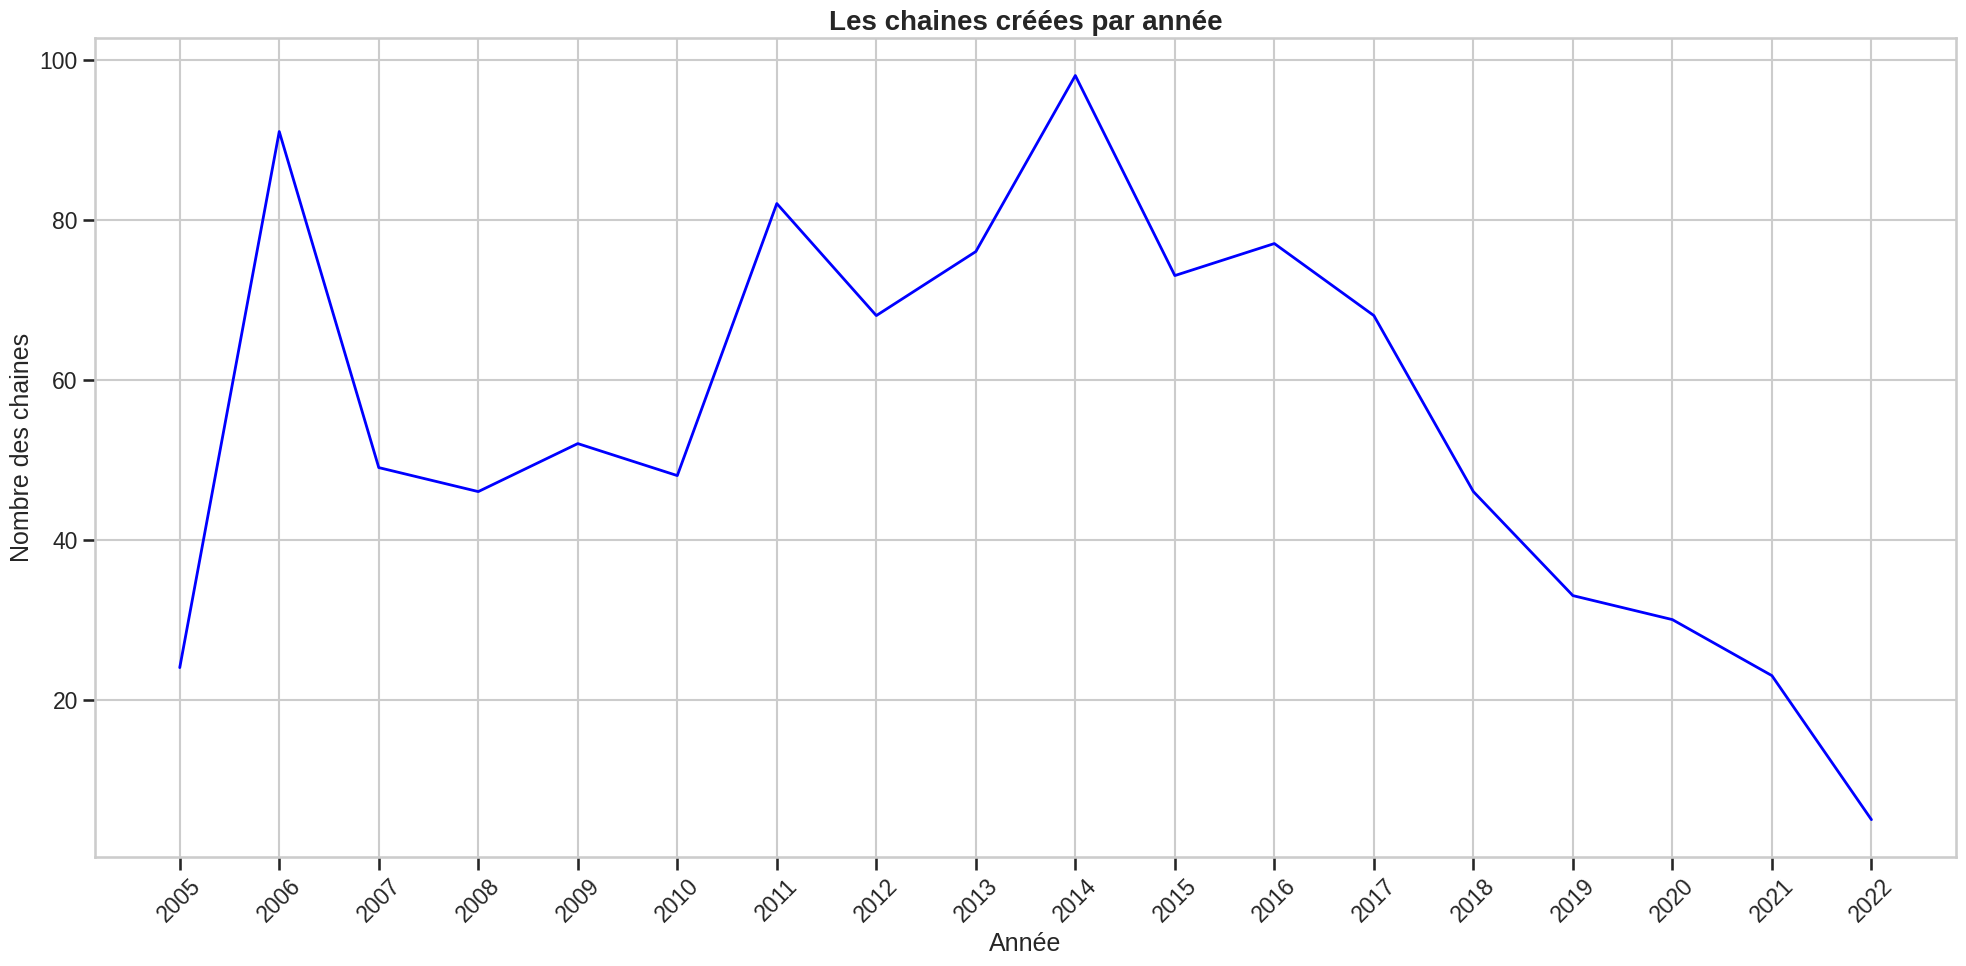

In [82]:
# Style général
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")
grouped = df.groupby("created_complete_date")["Youtuber"].count()

x = grouped.index
y = grouped.values

plt.figure(figsize=(20, 10))
plt.plot(x, y , linestyle='-', color='b',linewidth=2)
plt.title("Les chaines créées par année", fontsize=20, weight="bold")
plt.xlabel("Année")
plt.ylabel("Nombre des chaines")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h1>Interpretation :</h1>

1. Présence de trois pics importants qui représentent les années ayant enregistré le plus grand nombre d’abonnés des chaînes.

2. L’évolution des chaînes créées a connu une augmentation au début (entre 2005 et 2006), suivie d’une diminution marquée entre 2006 et 2008 a cause de la crise financiere modiale de 2008. Par la suite, on observe une augmentation entre 2008 et 2014, puis une diminution progressive à partir de 2014.

<div style="
    background: linear-gradient(135deg, #f8fafc, #eef2ff);
    border-left: 6px solid #4f46e5;
    padding: 22px;
    border-radius: 14px;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 4px 14px rgba(0,0,0,0.08);
">

<h2 style="color:purple; margin-bottom:10px;">
graphique en aires</h2>

</div>

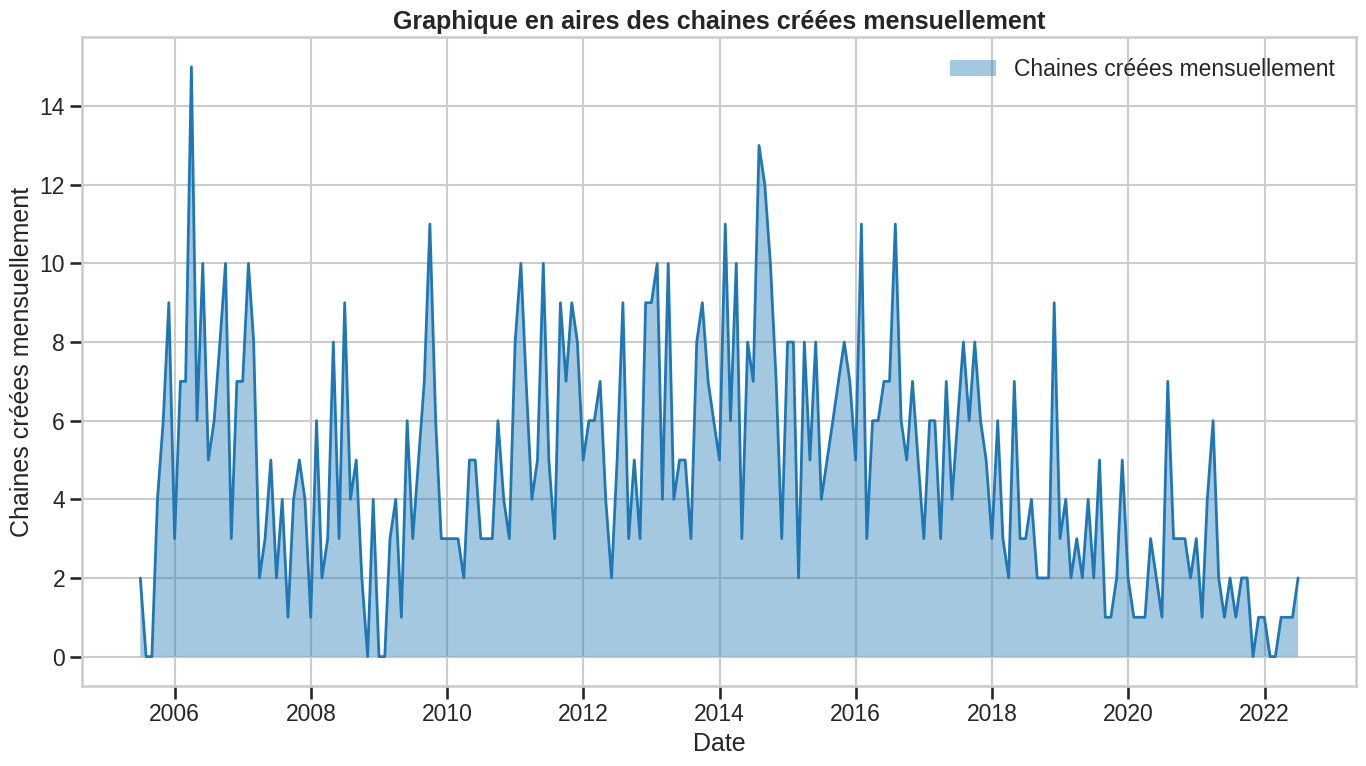

In [83]:
df['date']=pd.to_datetime(df["created_year"].astype(int).astype(str) 
                                             + "-" + df["created_month"].astype(str) 
                                             + "-" + df["created_date"].astype(int).astype(str) ,
                                             format="%Y-%b-%d" ,dayfirst=False).apply(lambda x: x.strftime("%Y-%m-%d"))
df["date"] = pd.to_datetime(df["date"])
monthly_channel = df.set_index("date")["Youtuber"].resample("ME").count()

plt.figure(figsize=(14, 8))

plt.fill_between(monthly_channel.index, monthly_channel.values, alpha=0.4, label="Chaines créées mensuellement")

plt.plot(monthly_channel.index, monthly_channel.values, linewidth=2)

plt.title("Graphique en aires des chaines créées mensuellement", fontsize=18, weight="bold")

plt.xlabel("Date")
plt.ylabel("Chaines créées mensuellement")

plt.legend()

plt.tight_layout()
plt.show()

<h1>Interpretation :</h1>


1. Les fluctuations mensuelles traduisent une variabilité élevée dans la création des chaînes.

2. Une tendance générale à la hausse au début et à la baisse à la fin.

3. L’existence de plusieurs pics,

4. Les périodes avec une surface importante correspondent à une forte activité globale.




<div style="
    background: linear-gradient(135deg, #f8fafc, #eef2ff);
    border-left: 6px solid #4f46e5;
    padding: 22px;
    border-radius: 14px;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 4px 14px rgba(0,0,0,0.08);
">

<h2 style="color:purple; margin-bottom:10px;">
Courbes multiples</h2>

</div>

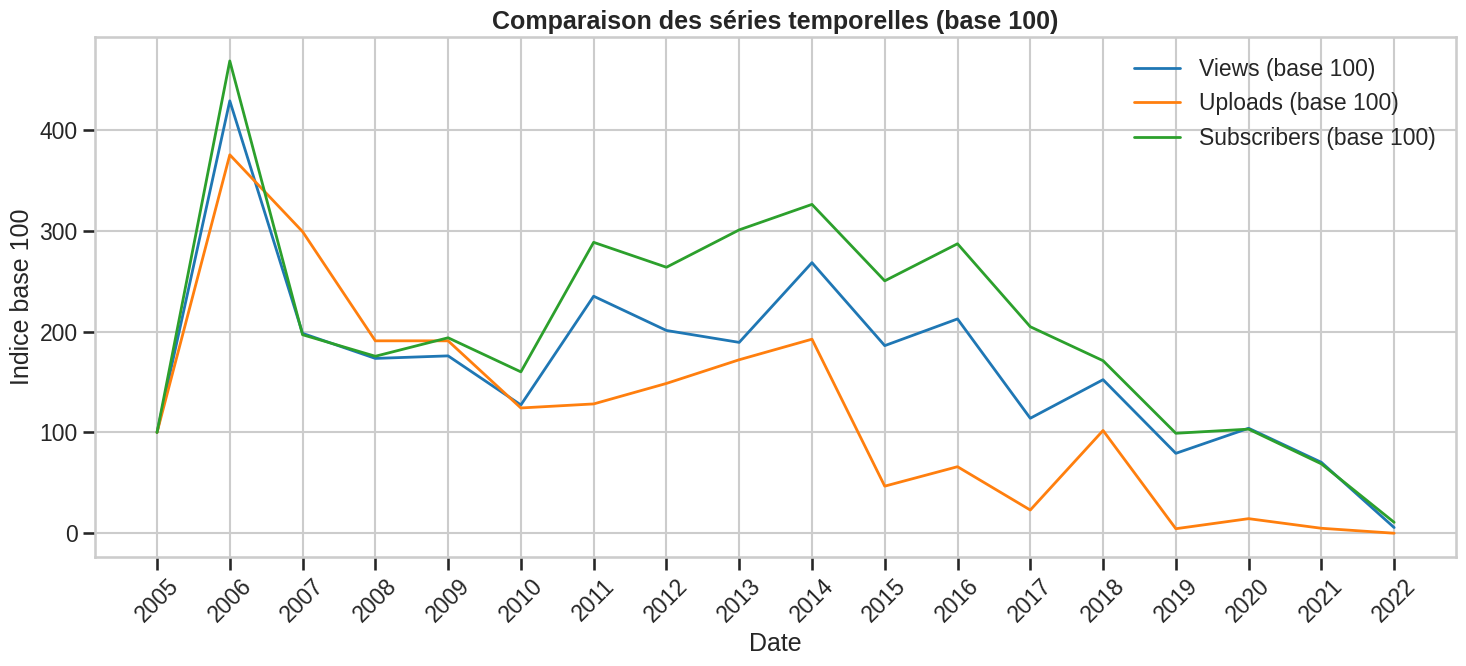

In [84]:
grouped_df = df.groupby("created_complete_date")[["video views", "uploads", "subscribers"]].sum().reset_index()
grouped_df = grouped_df.sort_values("created_complete_date")
base_values = grouped_df[["video views", "uploads", "subscribers"]].iloc[0]

grouped_df[["video views", "uploads", "subscribers"]] = (grouped_df[["video views", "uploads", "subscribers"]].div(base_values).mul(100))
plt.figure(figsize=(15, 7))

plt.plot(grouped_df["created_complete_date"], grouped_df["video views"], label="Views (base 100)", linewidth=2)
plt.plot(grouped_df["created_complete_date"], grouped_df["uploads"], label="Uploads (base 100)", linewidth=2)
plt.plot(grouped_df["created_complete_date"], grouped_df["subscribers"], label="Subscribers (base 100)", linewidth=2)

plt.title("Comparaison des séries temporelles (base 100)", fontsize=18, weight="bold")
plt.xlabel("Date")
plt.ylabel("Indice base 100")
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

<h1>Interpretation :</h2>

1. Les variables suivent la même évolution.

2. Les trois variables agissent les unes sur les autres.

3. Le nombre d'abonnés augmente rapidement par rapport aux vues et aux uploads entre 2005 et 2006.

4. Les upoalds diminuent rapidement par rapport aux abonnés et aux vues.

5. Les chaînes plus anciennes ont un nombre plus élevé d'abonnés, de vues et d’uploads .


<h1>Decision :</h2>

1) Analyser des facteurs de croissance et anticiper les périodes de baisse pour adapter une stratégie d’innovation et de contenu de qualité.

2) Exploiter les années pics pour comprendre les tendances et les nouveautés.

3) L’amélioration d’une variable peut influencer positivement sur les autres.



# Visualisation temporelle — Mettre en évidence une tendance


## 1. Courbe lissée — LOWESS

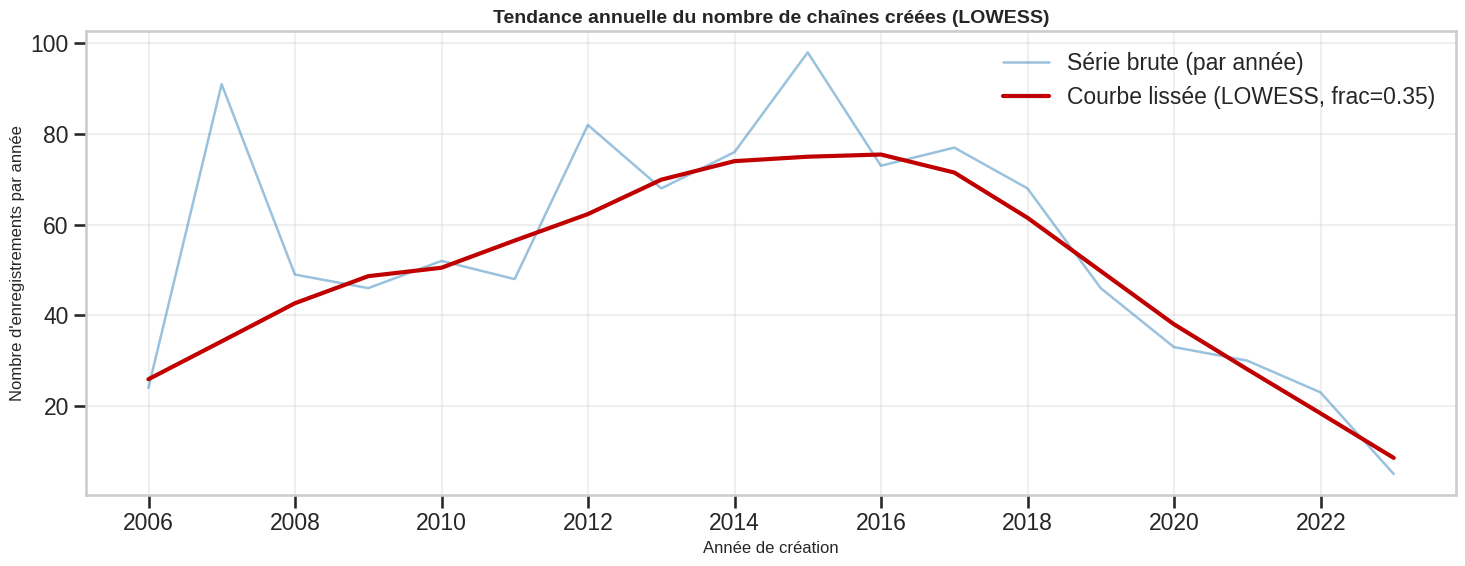

In [85]:
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# Préparer la série annuelle sur tout le dataset.
# On ne filtre pas sur Youtuber pour éviter un biais de sélection.
df["created_complete_date"] = pd.to_datetime(df["created_complete_date"], errors="coerce")

serie_annuelle = (df
                  .set_index("created_complete_date")
                  .resample("YE")
                  .size())

# LOWESS sur toute la série annuelle (y compris les années à 0).
x_num = np.arange(len(serie_annuelle))
frac_lowess = 0.35
y_lisse = lowess(serie_annuelle.values, x_num, frac=frac_lowess, return_sorted=False)

plt.figure(figsize=(15, 6))
plt.plot(serie_annuelle.index, serie_annuelle.values,
         label="Série brute (par année)", alpha=0.45, linewidth=1.8, color="#1F77B4")
plt.plot(serie_annuelle.index, y_lisse,
         label=f"Courbe lissée (LOWESS, frac={frac_lowess})", linewidth=3, color="#C00000")

plt.title("Tendance annuelle du nombre de chaînes créées (LOWESS)",
          fontsize=14, fontweight='bold')
plt.xlabel("Année de création", fontsize=12)
plt.ylabel("Nombre d'enregistrements par année", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interprétation et décision :**

- La **courbe brute** (bleue) représente le nombre d'enregistrements par année.
- La courbe LOWESS (rouge) lisse cette série annuelle complète pour faire ressortir la **tendance générale** : montée progressive jusqu'au **pic autour de 2014**, puis **décroissance** après 2018.
- Cette tendance descendante n'est pas forcément une baisse réelle des créations : c'est surtout un **biais de survie** (les chaînes récentes n'ont pas encore eu le temps d'entrer dans le top mondial).
- **Choix de `frac` :** `frac=0.35` donne un lissage suffisant pour une série annuelle, qui contient moins de points qu'une série mensuelle qui contient beaucoup de zero

- **Décision 
les chaine cree avant de 2014 et surtout au debut en 2006 ont la chance d etre classe parmi les top chaine youtube mondiale vu que la platforme est nouveau a cette epoque et la manque de concurrence mais a partir 2015 il ya un manque de chaine qui seront classifier au top mondial a cause du concurrence des chaine ancien deja exist . donc s il vous voulez que votre chaine sera classifier au top mondial il faut investir a elle au debut du lancement de la platforme youtube.

## 2. Moyenne mobile

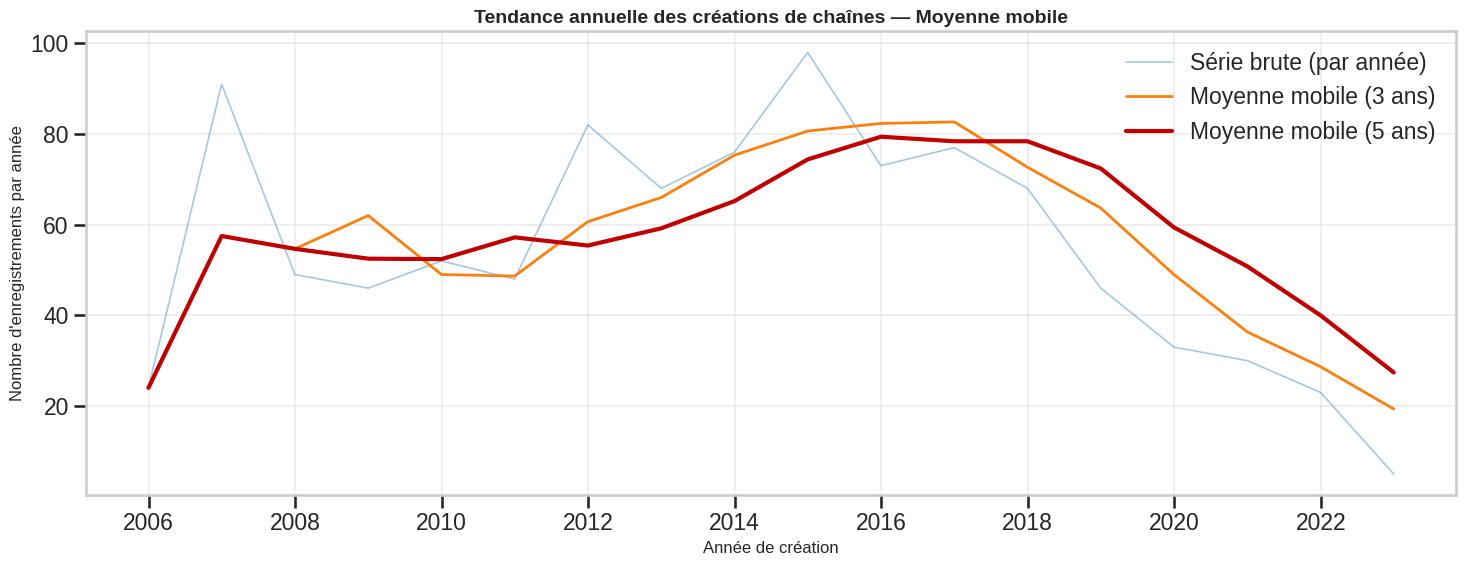

In [86]:
# --- Application sur le dataset YouTube ---
# Moyennes mobiles sur la série annuelle des créations
ma_3_ans = serie_annuelle.rolling(window=3, min_periods=1).mean()
ma_5_ans = serie_annuelle.rolling(window=5, min_periods=1).mean()

plt.figure(figsize=(15, 6))
plt.plot(serie_annuelle.index, serie_annuelle.values,
         alpha=0.4, label="Série brute (par année)", linewidth=1.2, color="#1F77B4")
plt.plot(ma_3_ans.index, ma_3_ans.values,
         linewidth=2, label="Moyenne mobile (3 ans)", color="#FF7F0E")
plt.plot(ma_5_ans.index, ma_5_ans.values,
         linewidth=3, label="Moyenne mobile (5 ans)", color="#C00000")

plt.title("Tendance annuelle des créations de chaînes — Moyenne mobile",
          fontsize=14, fontweight='bold')
plt.xlabel("Année de création", fontsize=12)
plt.ylabel("Nombre d'enregistrements par année", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interprétation et décision (Moyenne mobile) :**

- La **MA(3 ans)** est plus réactive : elle suit davantage les variations récentes de la série annuelle.
- La **MA(5 ans)** est plus lisse et révèle mieux la **tendance de fond** : montée jusqu'à ~2014, puis baisse progressive après les années de pic.
- Les deux fenêtres confirment le même message global que LOWESS : hausse, pic autour de 2014, puis baisse progressive.
- **Limite importante de la moyenne mobile :** elle est **retardée** (effet de décalage), car elle utilise surtout les valeurs passées.
- **Décision analytique :**
  - **MA(5 ans)** : adaptée pour montrer une tendance annuelle stable.
  - **MA(3 ans)** : plus réactive pour repérer les changements récents.
- **Décision pratique :** utiliser la moyenne mobile pour compléter la lecture LOWESS, en gardant à l'esprit le biais de sélection/survie du dataset.

## 3. Comparaison — Courbe lissée (LOWESS) vs Moyenne mobile

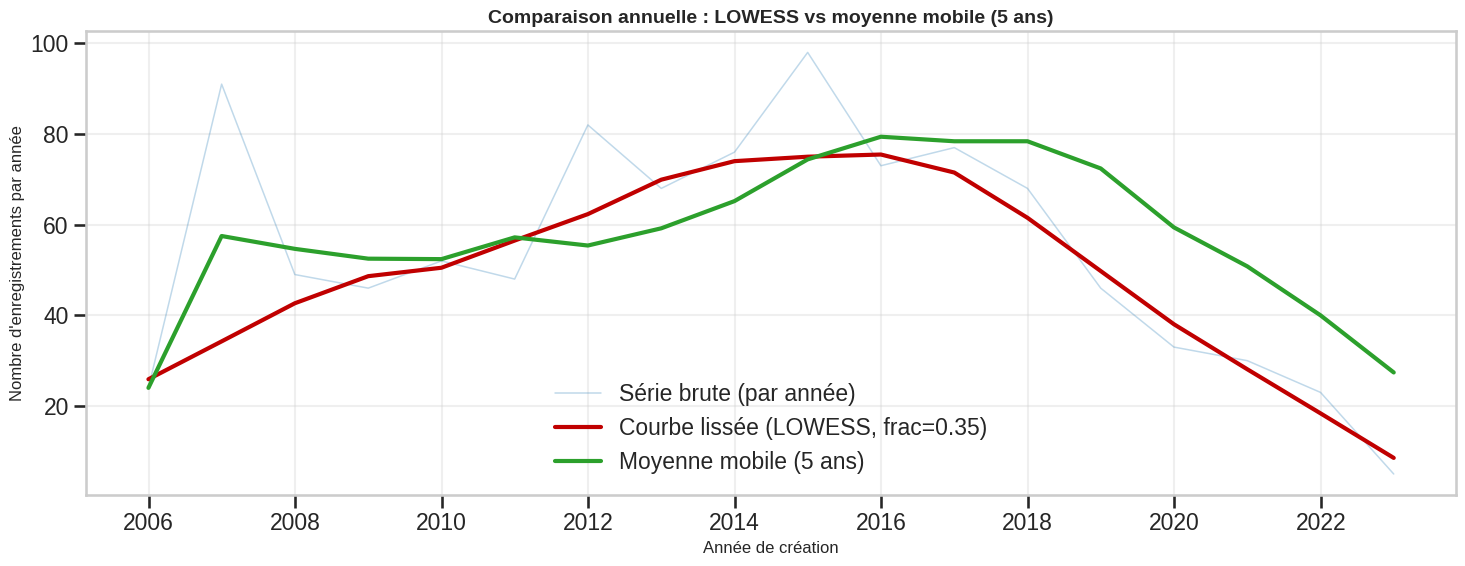

In [87]:
# Comparaison : série annuelle brute + courbe lissée (LOWESS) + moyenne mobile (5 ans)
plt.figure(figsize=(15, 6))

plt.plot(serie_annuelle.index, serie_annuelle.values,
         label="Série brute (par année)", alpha=0.28, linewidth=1.1, color="#1F77B4")

plt.plot(serie_annuelle.index, y_lisse,
         label=f"Courbe lissée (LOWESS, frac={frac_lowess})", linewidth=3, color="#C00000")

plt.plot(ma_5_ans.index, ma_5_ans.values,
         label="Moyenne mobile (5 ans)", linewidth=3, color="#2CA02C")

plt.title("Comparaison annuelle : LOWESS vs moyenne mobile (5 ans)",
          fontsize=14, fontweight='bold')
plt.xlabel("Année de création", fontsize=12)
plt.ylabel("Nombre d'enregistrements par année", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interprétation et décision (Comparaison annuelle) :**
- Les deux méthodes convergent vers la même lecture annuelle : hausse jusqu’à environ 2014, puis baisse progressive.
- LOWESS met mieux en évidence les changements de pente ; la moyenne mobile sur 5 ans donne une lecture plus stable mais légèrement retardée.
- La cohérence entre les deux approches renforce la crédibilité de la tendance observée sur les années.
- **Décision finale :**
  - pour expliquer la tendance annuelle dans un rapport : privilégier LOWESS ;
  - pour une lecture plus stable de l'évolution annuelle : utiliser la moyenne mobile sur 5 ans ;
  - dans les deux cas, rappeler la limite principale du dataset (top mondial = biais de sélection/survie).

<div style="
    background: linear-gradient(135deg, #f8fafc, #eef2ff);
    border-left: 6px solid #4f46e5;
    padding: 22px;
    border-radius: 14px;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 4px 14px rgba(0,0,0,0.08);
">

<h2 style="color:purple; margin-bottom:10px;">
     Courbe par période - video views
</h2>

</div>

In [88]:
# Transform values to billion to normalize the column
data = df.copy()
# transform the month column to the correct format
data["created_month"] = pd.to_datetime(df["created_month"].astype(str) , format="%b" , dayfirst=False).apply(lambda x : x.strftime("%m"))
data["video views"] = data["video views"].apply(lambda x : x / 1e9)

In [89]:
# Moyenne des views par mois et par année
courbe_periode = data.groupby(["created_year", "created_month"] )["video views"].mean().unstack()  ## the indexes ( year & month) turn to labels
courbe_periode

created_month,01,02,03,04,05,06,07,08,09,10,11,12
created_year,,,,,,,,,,,,
2005.0,NaN,NaN,NaN,NaN,NaN,7.719450,NaN,NaN,12.388146,14.049172,14.495019,27.496747
2006.0,8.516085,3.347126,25.963440,15.372657,8.527945,15.256363,8.804935,17.113625,45.065967,9.696982,11.475295,10.878863
2007.0,13.342716,15.625374,6.575413,12.989582,25.351023,14.932086,11.714763,101.000000,9.353054,5.645433,6.167161,12.607489
2008.0,13.131282,12.221181,11.201338,9.821134,13.123631,18.671315,20.026062,8.870790,9.033826,NaN,15.676229,NaN
2009.0,NaN,8.526200,8.258300,7.102966,19.269294,10.031079,6.662000,11.291329,14.949305,11.778895,11.439554,14.643284
2010.0,9.764066,2.154149,16.074181,11.215175,11.025406,13.615375,5.118180,2.753771,9.923944,10.183272,14.002336,9.401802
2011.0,8.982491,10.919285,7.879161,5.429896,12.788512,25.934534,6.236249,7.763901,9.635121,9.178041,7.322587,14.310660
2012.0,8.379895,12.662697,14.067226,12.457677,10.336027,6.090371,8.815913,9.358136,12.570294,7.481190,13.988064,9.334421
2013.0,11.465148,17.893122,8.823663,3.740681,12.287821,10.030703,6.077422,7.236484,5.318108,9.832748,13.684336,1.922000


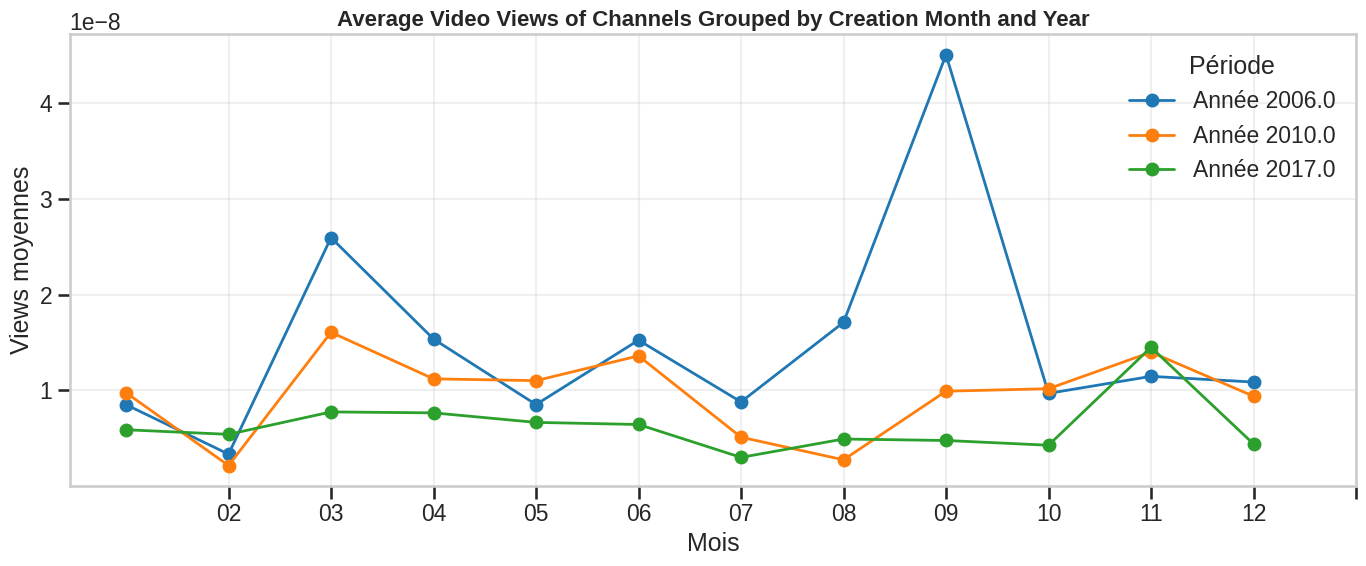

In [90]:
# keep just the years 2006, 2010, 2017
periode_2006_2010_2017 = courbe_periode[
    courbe_periode.index.isin([2006, 2010, 2017])
]

# Tracé
plt.figure(figsize=(14, 6))

for annee in periode_2006_2010_2017.index:
    plt.plot(
        periode_2006_2010_2017.columns,
        periode_2006_2010_2017.loc[annee].apply(lambda x : x / 1e9),
        marker="o",
        linewidth=2,
        label=f"Année {annee}"
    )

plt.title("Average Video Views of Channels Grouped by Creation Month and Year", fontsize=16, weight="bold")
plt.xlabel("Mois")
plt.ylabel("Views moyennes")

plt.xticks(range(1, 13) , )

plt.legend(title="Période")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
- De manière générale, après avoir regroupé les chaînes YouTube selon leur mois et leur année de création, on remarque que le facteur temps influence directement le volume de vues générées. Les chaînes créées en 2006 présentent globalement des valeurs de video views plus élevées que celles créées en 2010, qui elles-mêmes dépassent généralement celles créées en 2017.

- Cette tendance peut s’expliquer par le fait que les chaînes les plus anciennes ont eu plus de temps pour publier du contenu, développer leur audience et accumuler des vues au fil des années.

- Au-delà de l'effet de l'ancienneté, le graphique des vues moyennes révèle également des effets de mois de création. Les chaînes créées en mars enregistrent systématiquement des vues moyennes plus élevées pour les trois années étudiées, tandis que celles créées en février présentent un creux qualitatif cohérent sur l'ensemble des années. On note également un pic exceptionnel en septembre 2006, qui ne se reproduit pas pour 2010 et 2017 et s'apparente davantage à une anomalie historique liée aux débuts de YouTube qu'à un effet saisonnier généralisable. Il convient donc de parler d'effets de mois plutôt que de saisonnalité au sens strict, ces effets restant partiels et non uniformes selon les années.
---

<div style="
    background: linear-gradient(135deg, #f8fafc, #eef2ff);
    border-left: 6px solid #4f46e5;
    padding: 22px;
    border-radius: 14px;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 4px 14px rgba(0,0,0,0.08);
">

<h2 style="color:purple; margin-bottom:10px;">
     Heatmap temporelle
</h2>

</div>

In [91]:
# create dynamic table
pivot_heatmap = data.pivot_table(
    values="video views",
    index="created_year",
    columns="created_month",
    aggfunc="mean"
)
pivot_heatmap

created_month,01,02,03,04,05,06,07,08,09,10,11,12
created_year,,,,,,,,,,,,
2005.0,NaN,NaN,NaN,NaN,NaN,7.719450,NaN,NaN,12.388146,14.049172,14.495019,27.496747
2006.0,8.516085,3.347126,25.963440,15.372657,8.527945,15.256363,8.804935,17.113625,45.065967,9.696982,11.475295,10.878863
2007.0,13.342716,15.625374,6.575413,12.989582,25.351023,14.932086,11.714763,101.000000,9.353054,5.645433,6.167161,12.607489
2008.0,13.131282,12.221181,11.201338,9.821134,13.123631,18.671315,20.026062,8.870790,9.033826,NaN,15.676229,NaN
2009.0,NaN,8.526200,8.258300,7.102966,19.269294,10.031079,6.662000,11.291329,14.949305,11.778895,11.439554,14.643284
2010.0,9.764066,2.154149,16.074181,11.215175,11.025406,13.615375,5.118180,2.753771,9.923944,10.183272,14.002336,9.401802
2011.0,8.982491,10.919285,7.879161,5.429896,12.788512,25.934534,6.236249,7.763901,9.635121,9.178041,7.322587,14.310660
2012.0,8.379895,12.662697,14.067226,12.457677,10.336027,6.090371,8.815913,9.358136,12.570294,7.481190,13.988064,9.334421
2013.0,11.465148,17.893122,8.823663,3.740681,12.287821,10.030703,6.077422,7.236484,5.318108,9.832748,13.684336,1.922000


In [92]:
mois = {
    "01": "Jan",
    "02": "Fév",
    "03": "Mar",
    "04": "Avr",
    "05": "Mai",
    "06": "Juin",
    "07": "Juil",
    "08": "Aoû",
    "09": "Sep",
    "10": "Oct",
    "11": "Nov",
    "12": "Déc"
}

In [93]:
# Transform columns [ months ] to abbreviate format
pivot_heatmap.columns = [mois[m] for m in pivot_heatmap.columns]

In [94]:
# work with data comming form years 2006 , 2010 , 2017
pivot_heatmap_2006_2010_2017 = pivot_heatmap[pivot_heatmap.index.isin([2006,2010,2017])]

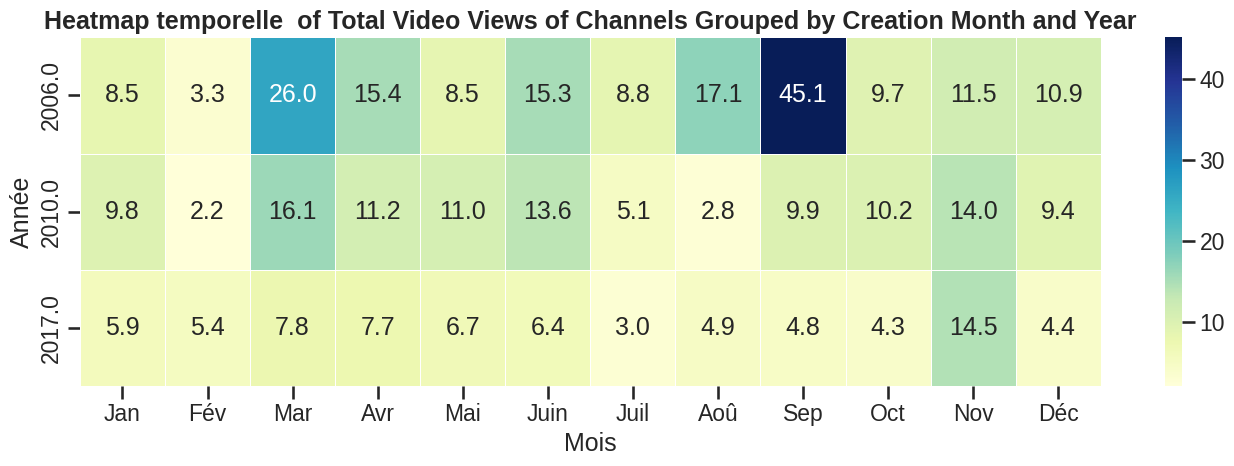

In [95]:
plt.figure(figsize=(14, 5))
sns.heatmap(pivot_heatmap_2006_2010_2017, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5)

plt.title("Heatmap temporelle  of Total Video Views of Channels Grouped by Creation Month and Year", fontsize=18, weight="bold")

plt.xlabel("Mois")
plt.ylabel("Année")

plt.tight_layout()
plt.show()

---
- La heatmap confirme que l'ancienneté est le principal déterminant du volume de vues, avec 2006 dominant largement. Toutefois, des effets de mois existent (Mars fort, Février faible) et des pics ponctuels (Sep 2006, Nov 2017) suggèrent l'influence de chaînes individuellement très performantes sur l'agrégat.
---

## Conclusion
---
- Cette analyse montre que le nombre de video views est fortement influencé par l’année de création des chaînes, car les chaînes les plus anciennes ont eu plus de temps pour accumuler des vues. On observe également certains effets liés au mois de création, notamment un pic régulier en mars et une baisse en février. Cependant, ces variations ne sont pas toujours uniformes selon les années, comme le montre le pic exceptionnel de septembre 2006. Ainsi, on peut parler d’effets de mois, mais pas d’une saisonnalité totalement généralisable.
---

In [96]:
import geopandas as gpd
import geodatasets
from shapely.geometry import LineString

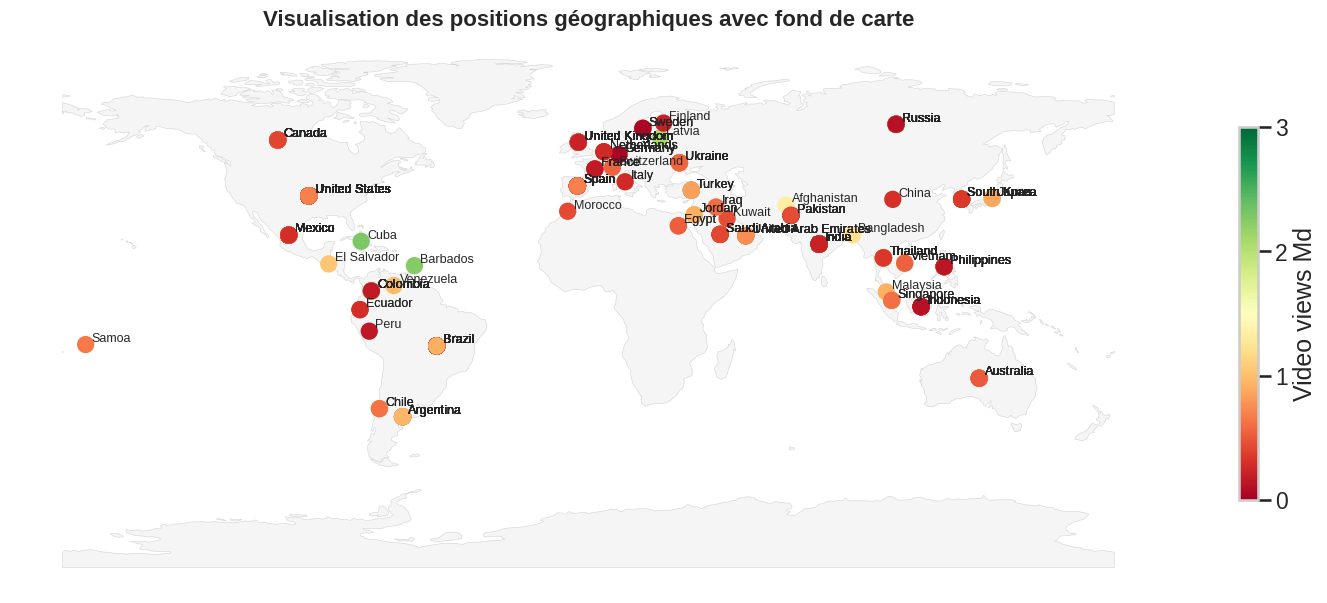

In [97]:
#Conversion en GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
)
#Chargement du fond de carte
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

#Visualisation avec fond de carte
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# fond de carte
world.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.4
)

# points
scatter = ax.scatter(
    gdf["Longitude"], gdf["Latitude"], c=gdf["video views"]/1e10,
    s=120,
    cmap="RdYlGn" , 
    vmin =0 ,
    vmax = 3)

# noms des villes
for i in range(len(gdf)):
    ax.text(
        gdf.iloc[i] ["Longitude"] + 2,
        gdf.iloc[i] ["Latitude"] + 1,
        gdf.iloc[i] ["Country"],
        fontsize=9
    )

# barre de couleur
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_label("Video views Md")
cbar.set_ticks([0, 1, 2, 3])

ax.set_title("Visualisation des positions géographiques avec fond de carte", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()



<div style="border-left:6px solid #8cc6ed; padding:12px; background:#f4f8fb; border-radius:10px; max-width:98%">

#### **Repérer des anomalies** </div>




<div style="border-left:6px solid #c5cace; padding:11px; background:#f4f8fb; border-radius:10px; max-width:98%">

#### **Courbe avec points marqués** </div>


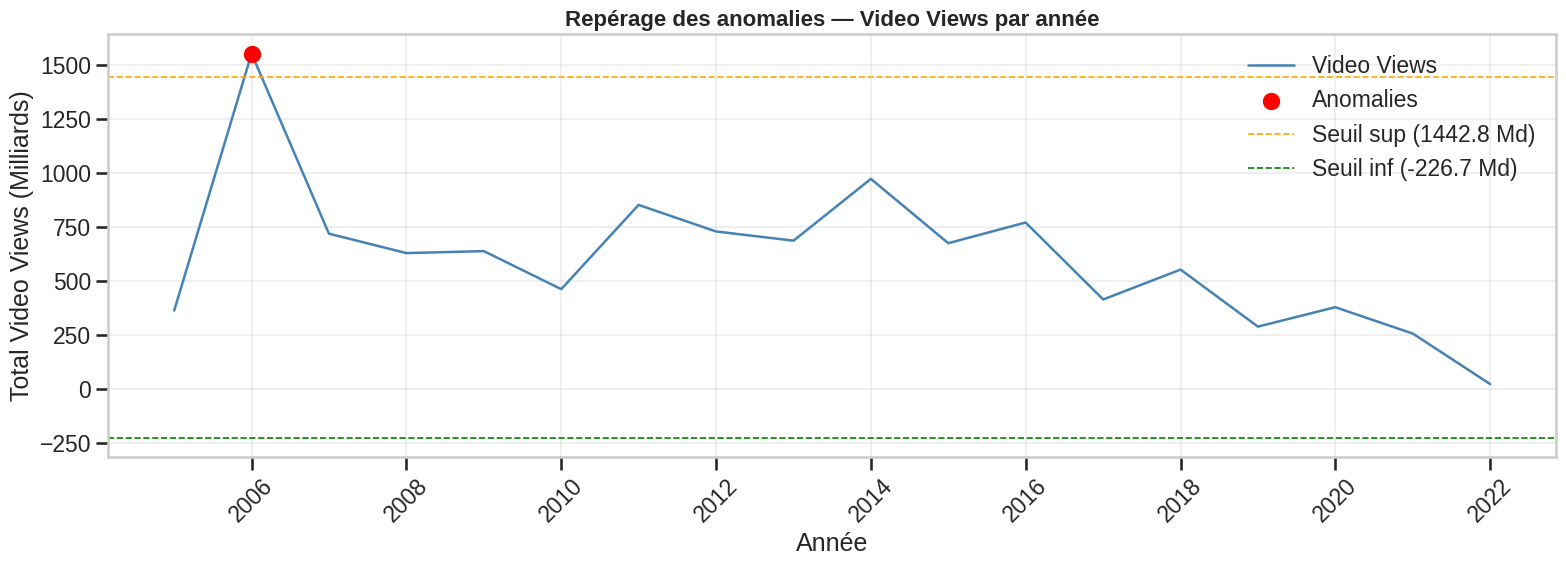


Moyenne : 608.06 Md | Écart-type : 333.90 Md
Seuil sup : 1442.82 Md | Seuil inf : -226.70 Md

Années anomales détectées :
        date  video_views
1 2006-01-01  1552.259607


In [98]:

# --- Préparation (suite de votre notebook) ---
grouped = df.groupby("created_complete_date")["video views"].sum().reset_index()
grouped.columns = ["date", "video_views"]
grouped["video_views"] = grouped["video_views"] / 1e9  

# --- Moyenne et écart-type ---
moyenne = grouped["video_views"].mean()
ecart_type = grouped["video_views"].std()

# --- Détection des anomalies ---
seuil_sup = moyenne + 2.5 * ecart_type
seuil_inf = moyenne - 2.5 * ecart_type

anomalies = grouped[(grouped["video_views"] > seuil_sup) | (grouped["video_views"] < seuil_inf)]

# --- Tracé ---
plt.figure(figsize=(16, 6))
plt.plot(grouped["date"], grouped["video_views"], label="Video Views", linewidth=1.8, color="steelblue")
plt.scatter(anomalies["date"], anomalies["video_views"], label="Anomalies", s=120, color="red", marker="o", zorder=5)

# Lignes des seuils
plt.axhline(seuil_sup, color="orange", linestyle="--", linewidth=1.2, label=f"Seuil sup ({seuil_sup:.1f} Md)")
plt.axhline(seuil_inf, color="green",  linestyle="--", linewidth=1.2, label=f"Seuil inf ({seuil_inf:.1f} Md)")

plt.title("Repérage des anomalies — Video Views par année", fontsize=16, weight="bold")
plt.xlabel("Année")
plt.ylabel("Total Video Views (Milliards)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nMoyenne : {moyenne:.2f} Md | Écart-type : {ecart_type:.2f} Md")
print(f"Seuil sup : {seuil_sup:.2f} Md | Seuil inf : {seuil_inf:.2f} Md")
print(f"\nAnnées anomales détectées :\n{anomalies}")

### interprétation 
1. Une seule anomalie détectée : 2006
L'année 2006 dépasse le seuil supérieur (1341.7 Md) avec ~1400 Md de vues. C'est la seule valeur jugée statistiquement anormale par le modèle à 2.5σ.

2. Une tendance globale en cloche
Les vues augmentent de 2005 à 2006 (pic), chutent jusqu'en 2010, remontent jusqu'en 2014 (second pic ~950 Md), puis déclinent progressivement jusqu'en 2022 où elles tombent proches de 0.

3. Le pic de 2006 est suspect
Les chaînes créées en 2006 cumulent plus de vues que toutes les autres années. Cela peut s'expliquer par le fait que YouTube a été fondé en 2005 — les premières chaînes créées ont eu 18+ ans pour accumuler des vues, ce qui gonfle artificiellement ce chiffre.
4. La baisse post-2014 n'est pas un déclin réel
Les chaînes récentes (2018–2022) ont eu moins de temps pour accumuler des vues. Plus une chaîne est récente dans le dataset, moins elle a eu le temps de générer des vues — ce qui explique la descente progressive.

5. Le seuil inférieur est négatif (-254.9 Md)
Des vues ne peuvent pas être négatives, donc le seuil inférieur est théoriquement sans sens ici. Aucune anomalie "basse" n'est donc possible dans ce contexte.


<div style="border-left:6px solid #8cc6ed; padding:12px; background:#f4f8fb; border-radius:10px; max-width:98%">

#### **Analyser la fréquence ou la répartition des événements dans le temps** </div>




<div style="border-left:6px solid #c5cace; padding:11px; background:#f4f8fb; border-radius:10px; max-width:98%">

#### **Diagramme en barres par période** </div>

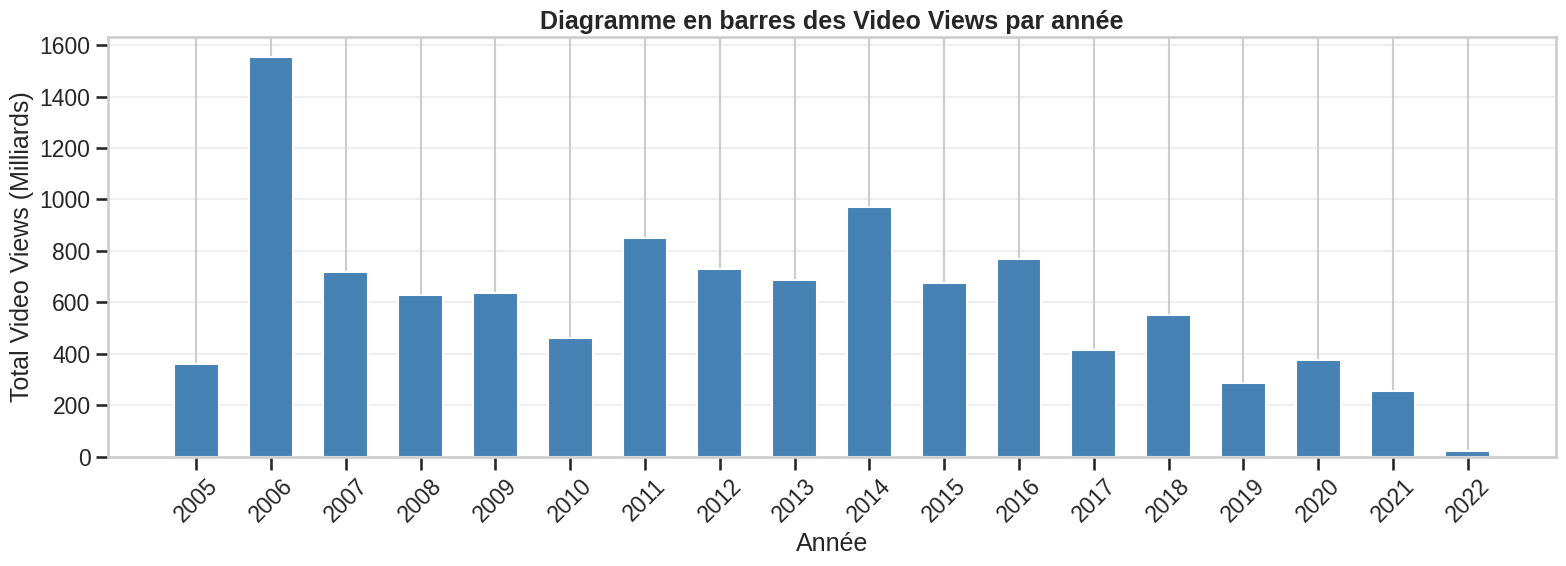

In [99]:
# Aggregation par année (resample nécessite un DatetimeIndex)
df_temp = df.copy()
df_temp["created_complete_date"] = pd.to_datetime(df_temp["created_complete_date"], format="%Y")
df_temp = df_temp.set_index("created_complete_date")

yearly_bar = df_temp["video views"].resample("YE").sum() / 1e9

# Tracé
plt.figure(figsize=(16, 6))
plt.bar(yearly_bar.index.year, yearly_bar.values, width=0.6, color="steelblue", edgecolor="white")

plt.title("Diagramme en barres des Video Views par année", fontsize=18, weight="bold")
plt.xlabel("Année")
plt.ylabel("Total Video Views (Milliards)")
plt.xticks(yearly_bar.index.year, rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### interprétation 
- 2006 domine largement (~1400 Md) — même explication : chaînes les plus anciennes, plus de temps pour accumuler des vues.

- 2010 est le creux (~400 Md) — année creuse en termes de chaînes créées ou de vues générées.

- 2011 et 2014 sont des pics secondaires (~800 et ~950 Md) — deux vagues de création de chaînes populaires.

- Déclin continu après 2014 — les chaînes récentes n'ont pas encore eu le temps de générer des vues significatives.

- 2022 quasi à 0 — données probablement incomplètes ou chaînes trop récentes.

## Décisions

1. Créer sa chaîne le plus tôt possible
L'ancienneté est le facteur n°1 de vues cumulées — chaque année perdue représente des centaines de milliards de vues en moins sur le long terme. La durée bat le volume de contenu.

2. Cibler les niches des pics 2011 et 2014
Ces années représentent les types de contenu les plus performants hors anomalie. Identifier ces catégories et les moderniser est la stratégie de contenu la plus rentable.

3. Concentrer les efforts sur les marchés dominants
La carte géographique a révélé que quelques pays génèrent l'essentiel des vues. Produire du contenu adapté à ces marchés prioritaires multiplie l'impact sans multiplier les efforts.

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import geodatasets
from shapely.geometry import LineString
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
df = pd.read_csv(r"/home/umoujahid/visualisation_project/data/Global-YouTube-Statistics_duplicates_dropped.csv")
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [101]:
df.dropna(subset=["Latitude","Longitude","Country","uploads","subscribers","created_year"] , inplace =True)

In [102]:
grouped = df.groupby("Country" ,as_index=False).agg({
    "video views" : "sum",
    "uploads":"sum",
    "subscribers":"sum",
    "Latitude": lambda x : x.mode().iloc[0] ,
    "Longitude" : lambda x : x.mode().iloc[0]
}).sort_values(by="video views" , ascending=False)

grouped.head()

,Country,video views,uploads,subscribers,Latitude,Longitude
45,United States,3.684603e+12,1299609,7315100000,37.090240,-95.712891
17,India,2.281048e+12,3728212,4310600000,20.593684,78.962880
5,Brazil,4.787683e+11,168178,1207300000,-14.235004,-51.925280
44,United Kingdom,4.305665e+11,86816,917400000,55.378051,-3.435973
40,Thailand,2.643180e+11,858953,386500000,15.870032,100.992541


### Carte de Points (Répartition mondiale des Views)

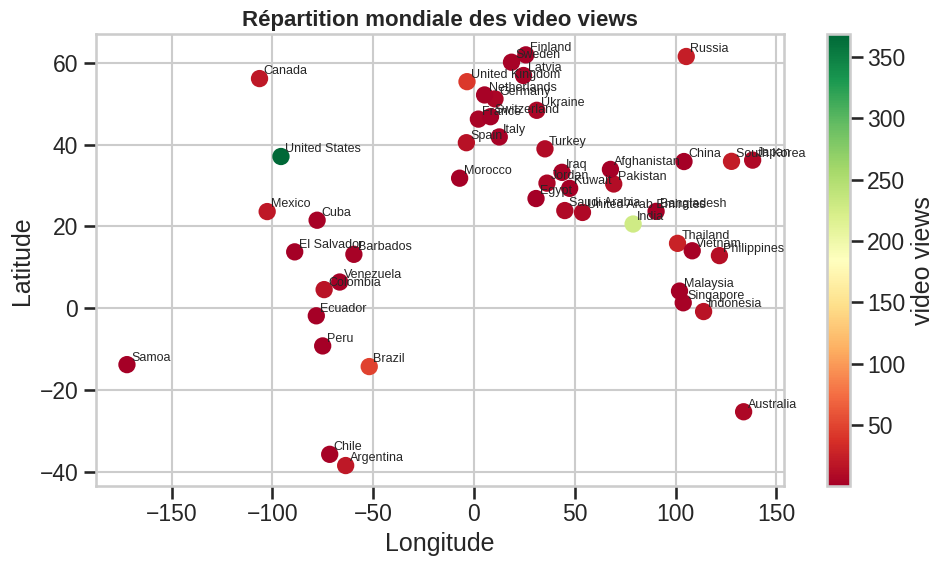

In [103]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

scatter = ax.scatter(
    grouped["Longitude"], grouped["Latitude"],
    c=grouped["video views"] / 1e10,
    s=120,
    cmap="RdYlGn"
)

for i in range(len(grouped)):
    ax.text(
        grouped.iloc[i]["Longitude"] + 2,
        grouped.iloc[i]["Latitude"] + 1,
        grouped.iloc[i]["Country"],
        fontsize=9
    )

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("video views")

ax.set_title("Répartition mondiale des video views", fontsize=16, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

### Carte de Points avec fond de carte  (Répartition mondiale des Views)

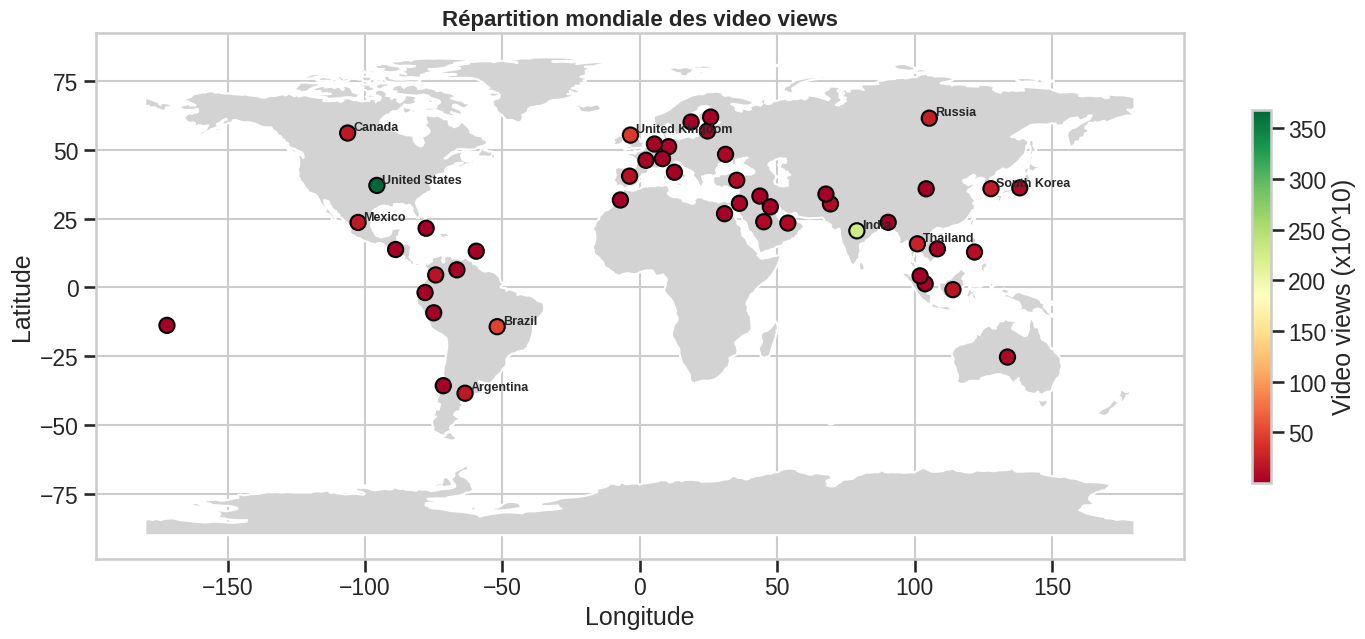

In [104]:
# Charger le fond de carte du monde
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

#  Créer la figure
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Afficher le fond de carte (en gris clair)
world.plot(ax=ax, color='lightgrey', edgecolor='white')

# Ajouter tes données par-dessus
scatter = ax.scatter(
    grouped["Longitude"], grouped["Latitude"],
    c=grouped["video views"] / 1e10,
    s=120,
    cmap="RdYlGn",
    edgecolor='black', 
    zorder=3           
)

for i in range(len(grouped.head(10))):
    ax.text(
        grouped.iloc[i]["Longitude"] + 2,
        grouped.iloc[i]["Latitude"] + 1,
        grouped.iloc[i]["Country"],
        fontsize=9, fontweight='bold'
    )

#  Barre de couleur et titres
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_label("Video views (x10^10)")

ax.set_title("Répartition mondiale des video views", fontsize=16, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

# interpretation 

Domination des États-Unis : Les chaînes basées aux États-Unis écrasent le marché mondial. Elles génèrent, de très loin, le plus gros volume de vues au monde (seul point vert foncé).

Puissance de l'Inde : L'Inde se distingue comme la deuxième puissance mondiale de création de contenu. Ses chaînes captent une part de vues massive, bien au-dessus de la moyenne des autres pays (point jaune/vert).

Faiblesse relative des autres pays : Que ce soit en Europe, en Amérique Latine ou en Asie du Sud-Est, les chaînes de ces régions (points rouges) produisent un volume de vues très faible en comparaison.

En résumé : Le paysage YouTube mondial est bipolaire. Le succès (en nombre de vues) est ultra-concentré : il appartient presque exclusivement aux chaînes américaines et indiennes. Le reste du monde, bien que présent, reste marginal en termes de poids numérique.

### Carte de Chaleur / Choroplèthe (Densité des Uploads)

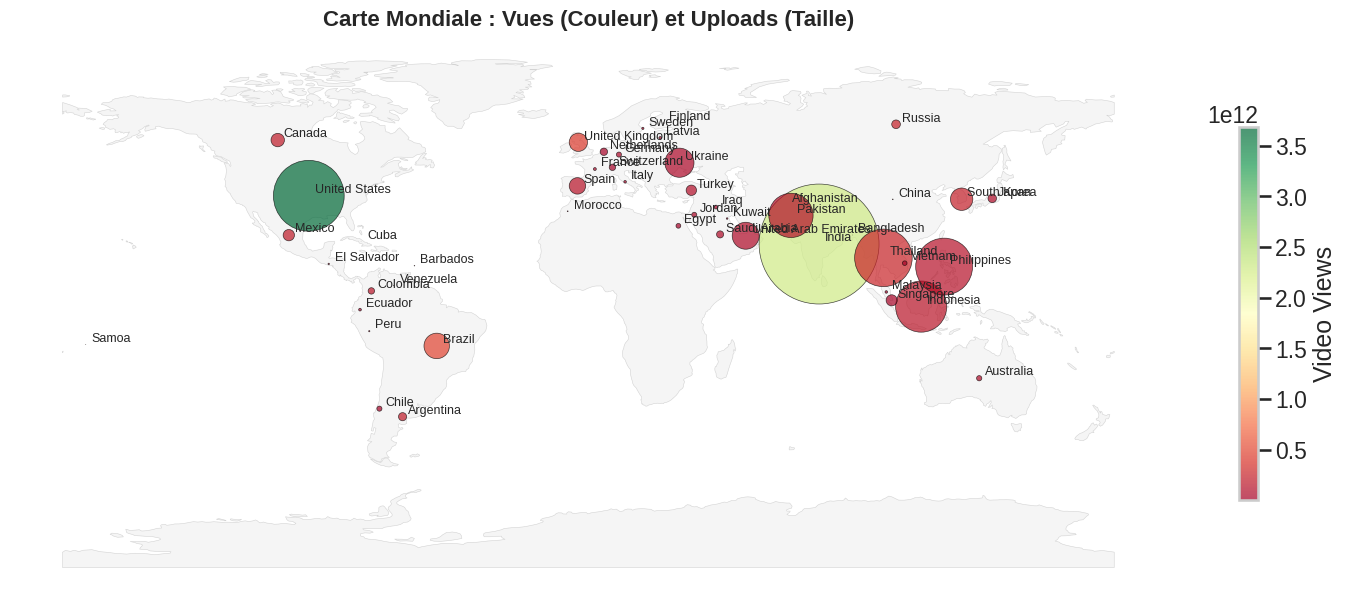

In [105]:
gdf = gpd.GeoDataFrame(
    grouped,
    geometry=gpd.points_from_xy(grouped["Longitude"], grouped["Latitude"]),
    crs="EPSG:4326"
)

# 2. Chargement du fond de carte
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

# 3. Création de la figure
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Fond de carte
world.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.4
)

# Points : couleur = video views, taille = uploads
scatter = ax.scatter(
    gdf["Longitude"],
    gdf["Latitude"],
    c=gdf["video views"],
    s=gdf["uploads"] / 500, 
    cmap="RdYlGn",
    alpha=0.7,
    edgecolors="black",
    linewidth=0.5
)

# Noms des pays
for i in range(len(gdf)):
    ax.text(
        gdf.iloc[i]["Longitude"] + 2,
        gdf.iloc[i]["Latitude"] + 1,
        gdf.iloc[i]["Country"],
        fontsize=9
    )

# Barre de couleur pour les vues
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_label("Video Views")

ax.set_title("Carte Mondiale : Vues (Couleur) et Uploads (Taille)", fontsize=16, fontweight="bold")
ax.set_axis_off()

plt.tight_layout()
plt.show()

## interpretation 

L'Inde est le pays qui publie le plus : C'est le leader mondial de la quantité (le plus grand nombre de vidéos mises en ligne).

Les États-Unis publient moins, mais sont plus vus : Ils privilégient l'impact (moins d'uploads que l'Inde, mais beaucoup plus de vues au total).

Le reste du monde produit peu : Tous les autres pays sont loin derrière, tant en nombre de vidéos publiées qu'en nombre de vues générées.

conclusion : L'Inde domine la production, les États-Unis dominent l'audience.

## Top 15 des Pays Leaders (3 variables associatives)

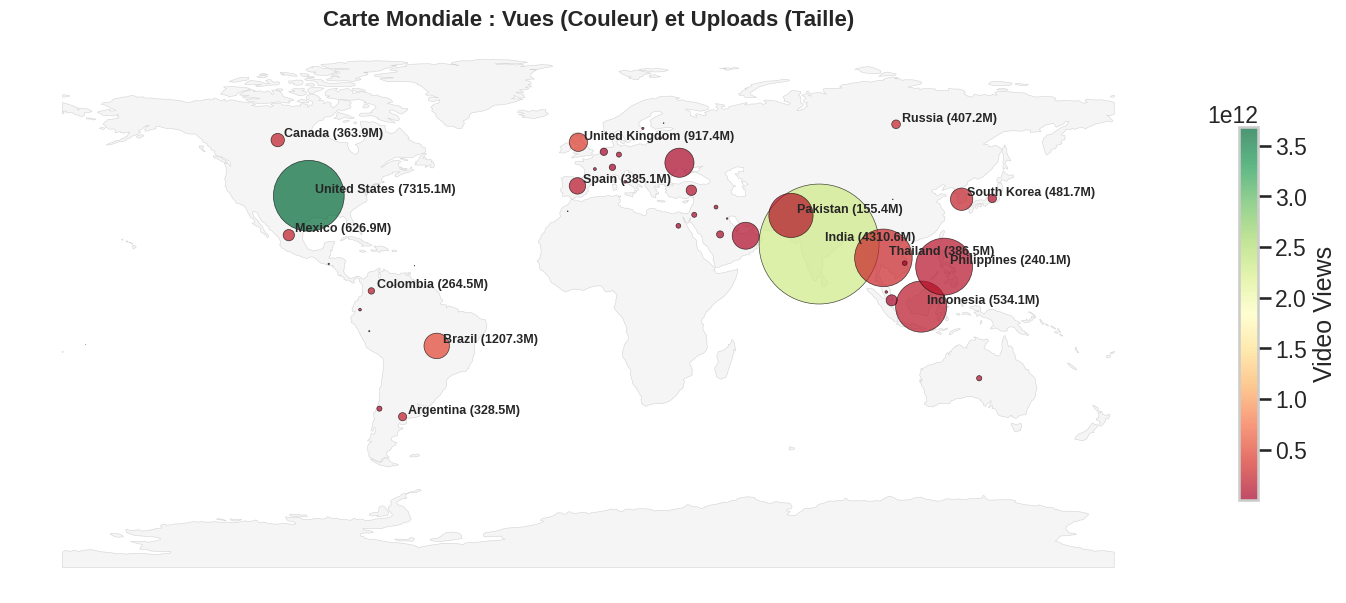

In [106]:
# 1. Création du GDF (votre code exact)
gdf = gpd.GeoDataFrame(
    grouped,
    geometry=gpd.points_from_xy(grouped["Longitude"], grouped["Latitude"]),
    crs="EPSG:4326"
)

# 2. Chargement du fond de carte
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

# 3. Création de la figure
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Fond de carte
world.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.4
)

# Points : couleur = video views, taille = uploads (taille augmentée pour lisibilité)
scatter = ax.scatter(
    gdf["Longitude"],
    gdf["Latitude"],
    c=gdf["video views"],
    s=gdf["uploads"] / 500, 
    cmap="RdYlGn",
    alpha=0.7,
    edgecolors="black",
    linewidth=0.5
)

# Noms des pays : Modification pour les 15 premiers uniquement + Subscribers en M
for i in range(min(15, len(gdf))):
    # Calcul des abonnés en millions
    subs_m = gdf.iloc[i]["subscribers"] / 1e6
    label = f"{gdf.iloc[i]['Country']} ({subs_m:.1f}M)"
    
    ax.text(
        gdf.iloc[i]["Longitude"] + 2,
        gdf.iloc[i]["Latitude"] + 1,
        label,
        fontsize=9,
        fontweight="bold"
    )

# Barre de couleur pour les vues
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_label("Video Views")

ax.set_title("Carte Mondiale : Vues (Couleur) et Uploads (Taille)", fontsize=16, fontweight="bold")
ax.set_axis_off()

plt.tight_layout()
plt.show()

## interpretation 

Le Duo de Tête (USA & Inde) : Ce sont les deux superpuissances. L'Inde est le leader de la production avec le record d'abonnés (4,3 Mds) et d'uploads (3,7 millions). Les États-Unis, bien que moins productifs en nombre de vidéos, restent les maîtres de l'audience avec le plus grand nombre de vues au monde (3,6 trillions).

L'Exception Brésilienne : C’est la troisième puissance mondiale. Avec plus d'1,2 milliard d'abonnés, le Brésil surclasse l'Europe et le reste de l'Asie, s'affirmant comme un moteur de croissance incontournable.

Le Groupe des Challengers : Des pays comme le Royaume-Uni, le Mexique ou la Thaïlande affichent des chiffres solides (entre 400M et 900M d'abonnés), mais ils restent loin derrière le trio de tête en termes de portée globale et de vues cumulées.                                                                                             conclusion : Le monde de YouTube est dominé par la productivité indienne et l'audience américaine, avec le Brésil comme principal moteur de croissance en dehors de ces deux géants.

# Analyse géo-temporelle ( comparer 2 dates )

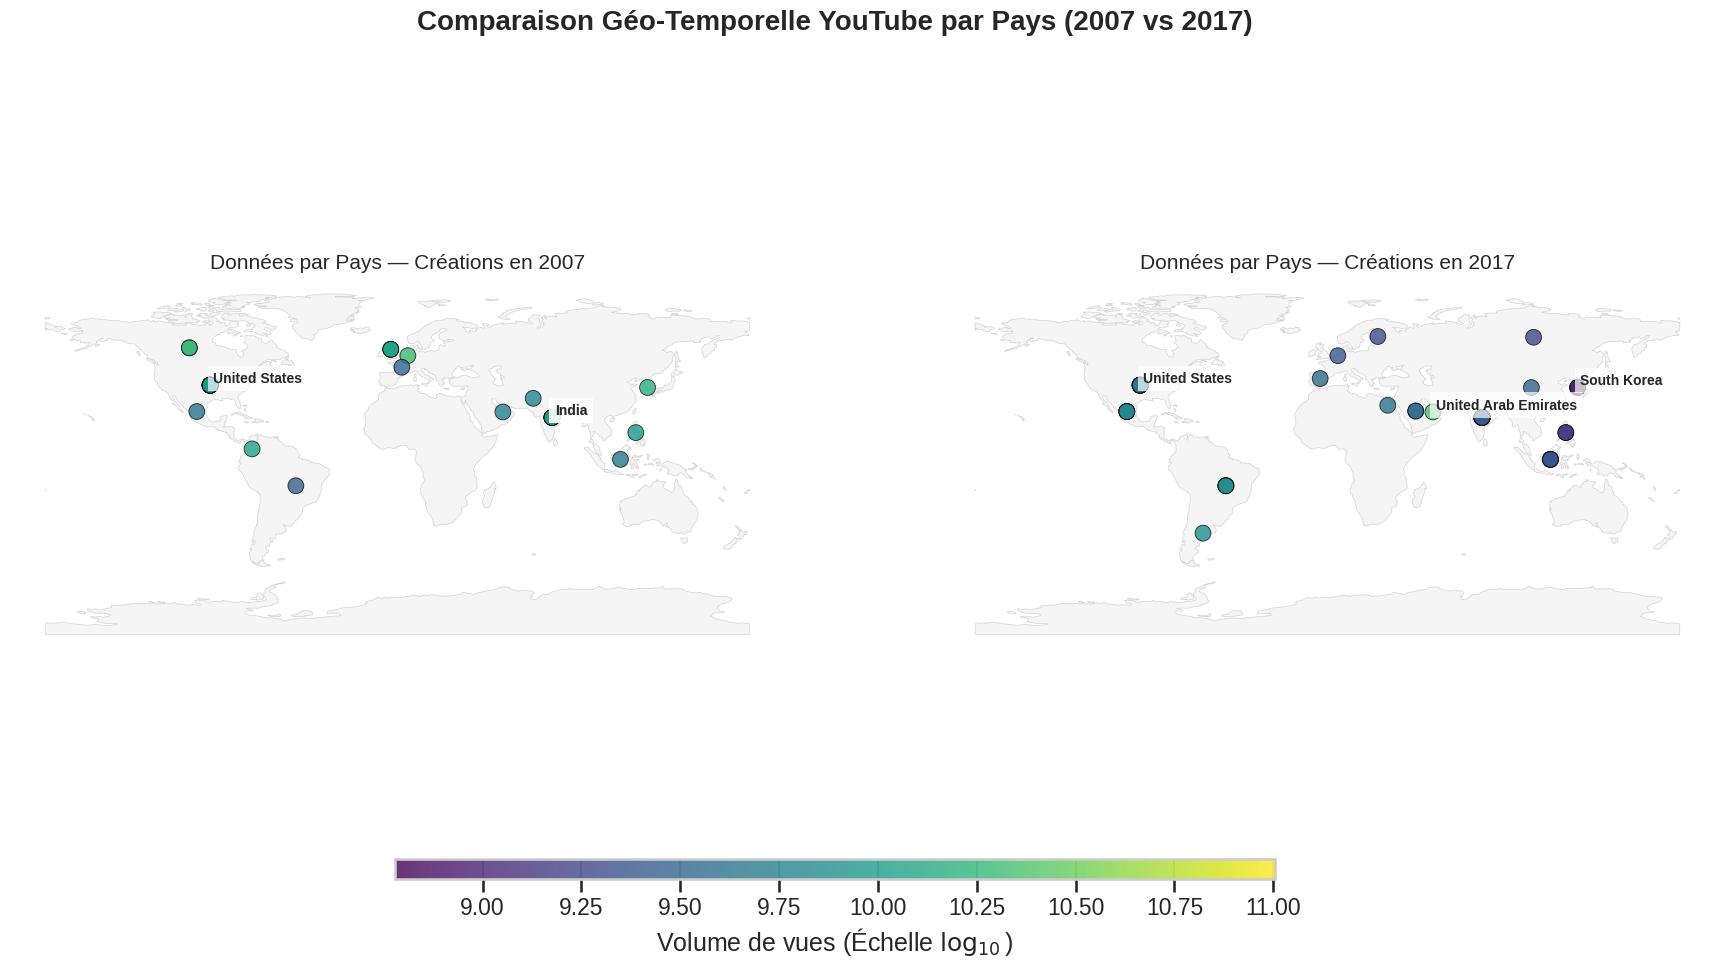

In [107]:
df_filtered = df[df["created_year"].isin([2007, 2017])]
df_filtered["log_views"] = np.log10(df_filtered["video views"] + 1)

#  Conversion en GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_filtered,
    geometry=gpd.points_from_xy(df_filtered["Longitude"], df_filtered["Latitude"]),
    crs="EPSG:4326"
)

#  Paramètres d'échelle communs pour une comparaison équitable
vmin = gdf["log_views"].min()
vmax = gdf["log_views"].max()

# Chargement du fond de carte mondial
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
annees = [2007, 2017]

for ax, annee in zip(axes, annees):
    data_annee = gdf[gdf["created_year"] == annee]
    world.plot(ax=ax, color="whitesmoke", edgecolor="lightgray", linewidth=0.5)
    
    # Affichage des points avec l'échelle fixe vmin/vmax
    scatter = ax.scatter(
        data_annee.geometry.x,
        data_annee.geometry.y,
        c=data_annee["log_views"], 
        s=130, 
        cmap="viridis",
        alpha=0.8,
        edgecolor="black",
        linewidth=0.6,
        vmin=vmin, 
        vmax=vmax
    )
    
    # Annotation des Pays (Top 3 par nombre de vues)
    top_pays = data_annee.nlargest(3, "video views")
    for x, y, country in zip(top_pays.geometry.x, top_pays.geometry.y, top_pays["Country"]):
        if country.strip():
            ax.text(x + 1.5, y + 1.5, country, fontsize=10, fontweight="bold", 
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax.set_title(f"Données par Pays — Créations en {annee}", fontsize=15)
    ax.set_axis_off()

# Barre de couleur commune en bas
cbar_ax = fig.add_axes([0.3, 0.08, 0.4, 0.02])
cbar = plt.colorbar(scatter, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Volume de vues (Échelle $\log_{10}$)")

plt.suptitle("Comparaison Géo-Temporelle YouTube par Pays (2007 vs 2017)", 
             fontsize=20, fontweight="bold", y=0.95)
plt.show()

## interpretation 

Avantage de l'ancienneté : Les chaînes créées en 2007 (points plus clairs/jaunes) ont un nombre de vues cumulées plus élevé. C'est logique : elles ont eu 10 ans de plus pour accumuler du trafic par rapport à celles de 2017.

Performance historique : Les leaders de 2007 (comme aux USA ou en Inde) restent des piliers massifs en termes de vues totales sur le long terme.

Exceptions en 2017 : Si 2007 domine globalement, certains points de 2017 (ex: Émirats Arabes Unis) sont presque aussi clairs, montrant que ces chaînes récentes ont rattrapé en seulement quelques années le volume de vues de chaînes beaucoup plus anciennes.

En résumé : la carte montre que l'ancienneté (2007) reste un facteur déterminant pour le score total de vues, malgré la montée en puissance rapide des créateurs de 2017.